# Fake News Detection — Retraining (On-the-fly Source Prefix Cleaning)

## How to Run This Notebook

Follow these steps to run the retraining pipeline successfully:

1. **Upload the required files** into the same working directory as the notebook:
   - `dataset/True.csv`
   - `dataset/Fake.csv`
   - `saved_models/tokenizer.json`  
   - This notebook file

2. **Open the notebook in Google Colab or Jupyter**.
   - In Colab, you can upload the files directly to the runtime or mount Google Drive.
   - Make sure the paths used in the code match where the files are stored.

3. **Run the cells in order from top to bottom**.
   - The notebook sets up imports, loads the dataset, cleans the text, tokenizes the articles, splits the data, trains the models, and saves the results.
   - Do not skip earlier cells, since later cells depend on variables created before them.

4. **Wait for training to finish**.
   - The notebook trains four models: **LSTM**, **GRU**, **Bidirectional LSTM**, and **CNN**.
   - Training may take several minutes depending on your hardware.

5. **Check the output folders and results**.
   - Trained weights are saved in the `saved_models/` directory.
   - The tokenizer file is also saved there and will be overwritten with the updated vocabulary.
   - Final metrics and confusion matrices will appear in the notebook output.

6. **Use the saved models in your app**.
   - After training completes, copy the saved weights and tokenizer into your Streamlit application or deployment folder as needed.

### Notes
- This notebook cleans real articles by removing source attribution prefixes like `WASHINGTON Reuters -` during preprocessing.
- For best results, run the notebook in a Python environment with enough memory and GPU support if available.
- If you rerun the notebook, existing files in `saved_models/` may be overwritten.

## 1. Setup & Imports

In [2]:
!pip install tensorflow

import os, re, json, warnings
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

MAX_VOCAB = 30_000
MAX_LEN = 300
EMBED_DIM = 64
BATCH_SIZE = 64
EPOCHS = 10
PATIENCE = 3

TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20

DATASET_DIR = 'dataset'
WEIGHTS_DIR = 'saved_models'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 798.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 80.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0
GPU: []


## 2. Load Original Dataset

In [3]:
df_fake = pd.read_csv(os.path.join(DATASET_DIR, 'Fake.csv'))
df_true = pd.read_csv(os.path.join(DATASET_DIR, 'True.csv'))
df_fake['label'] = 0
df_true['label'] = 1

df = pd.concat([df_fake, df_true], ignore_index=True)
print(f'Total dataset size: {len(df):,} rows')
print(f'Fake: {len(df_fake):,}  |  True: {len(df_true):,}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Total dataset size: 44,898 rows
Fake: 23,481  |  True: 21,417
Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


## 3. Text Cleaning & Preprocessing

**Key change:** `clean_text()` strips source-attribution prefixes from real articles
(e.g. `WASHINGTON (Reuters) - `) so the model learns content, not publication format.

In [4]:
# Source-attribution prefix patterns found in True.csv articles
# These appear at the START of the text and are stripped from real (label=1) articles
SOURCE_PREFIX_RE = re.compile(
    r'^(?:'
        r'[A-Za-z\s/]+?\s*'                  # Location: WASHINGTON, SEATTLE/WASHINGTON, etc.
        r'\((?:Reuters|AP|NYT|CNN|BBC|AFP|Non-US|Media|Verified)\)\s*'  # Source in parentheses
        r'-\s*'                              # Dash separator
    r'|'
        r'\((?:Reuters|AP|NYT|CNN|BBC|AFP|Non-US|Media|Verified)\)\s*-\s*'  # (Reuters) - alone
    r'|'
        r'By\s+[A-Za-z\s]+?\([A-Za-z]+\)\s*-\s*'  # By Author Name (Source) -
    r')+',
    re.IGNORECASE
)

def strip_source_prefix(text):
    """Strip source attribution prefix from the start of a real news article."""
    return SOURCE_PREFIX_RE.sub('', str(text), count=1)

def clean_text(text, label=None):
    """
    Clean article text for model input.
    - If label==1 (real), strip source attribution prefix first
    - Then: lowercase, remove URLs/HTML/punctuation, collapse whitespace
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    # Strip source prefix from real articles
    if label == 1:
        text = strip_source_prefix(text)
    # Standard cleaning
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Quick verify
print('=== Source prefix stripping examples ===')
for i, row in df_true.head(3).iterrows():
    original = str(row['text'])[:90]
    cleaned = strip_source_prefix(str(row['text']))[:90]
    print(f'ORIGINAL: {original}')
    print(f'CLEANED:  {cleaned}')
    print()

=== Source prefix stripping examples ===
ORIGINAL: WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress,
CLEANED:  The head of a conservative Republican faction in the U.S. Congress, who voted this month f

ORIGINAL: WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in 
CLEANED:  Transgender people will be allowed for the first time to enlist in the U.S. military start

ORIGINAL: WASHINGTON (Reuters) - The special counsel investigation of links between Russia and Presi
CLEANED:  The special counsel investigation of links between Russia and President Trump’s 2016 elect



In [5]:
# Combine title + text, then apply cleaning with label-aware source stripping
has_title = 'title' in df.columns
has_text = 'text' in df.columns

if has_title and has_text:
    df['combined'] = df['title'].fillna('').astype(str) + ' ' + df['text'].fillna('').astype(str)
elif has_text:
    df['combined'] = df['text'].fillna('').astype(str)
else:
    df['combined'] = df['title'].fillna('').astype(str)

# Apply label-aware cleaning (strips source prefix only for real articles)
df['cleaned'] = df.apply(lambda row: clean_text(row['combined'], row['label']), axis=1)

# Drop empty text / missing labels
before = len(df)
df = df[df['cleaned'].str.len() > 0]
df = df[df['label'].notna()]
df['label'] = df['label'].astype(int)
print(f'Dropped {before - len(df)} empty rows')
print(f'Clean dataset size: {len(df):,} rows')
print(f'Positive rate (real): {df["label"].mean():.2%}')

Dropped 9 empty rows
Clean dataset size: 44,889 rows
Positive rate (real): 47.71%


## 4. Tokenization & Padding

In [6]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned'].tolist())

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Vocab size: {vocab_size:,}')

# Save tokenizer (overwrites old one — new vocab reflects cleaned text)
tokenizer_path = os.path.join(WEIGHTS_DIR, 'tokenizer.json')
with open(tokenizer_path, 'w', encoding='utf-8') as f:
    f.write(tokenizer.to_json())
print(f'Tokenizer saved -> {tokenizer_path}')

sequences = tokenizer.texts_to_sequences(df['cleaned'].tolist())
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Vocab size: 30,000
Tokenizer saved -> saved_models/tokenizer.json
X shape: (44889, 300)
y shape: (44889,)


## 5. Train / Validation / Test Split

In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=SEED, stratify=y
)

val_size = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_size, random_state=SEED, stratify=y_trainval
)

print(f'Train:      {X_train.shape[0]:>7,}  ({X_train.shape[0]/len(X):.0%})')
print(f'Validation: {X_val.shape[0]:>7,}  ({X_val.shape[0]/len(X):.0%})')
print(f'Test:       {X_test.shape[0]:>7,}  ({X_test.shape[0]/len(X):.0%})')

Train:       31,422  (70%)
Validation:   4,489  (10%)
Test:         8,978  (20%)


## 6. Baseline Models

In [8]:
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'{name:<30}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}


all_metrics = []

for strategy in ('most_frequent', 'uniform', 'stratified'):
    clf = DummyClassifier(strategy=strategy, random_state=SEED)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    m = evaluate_model(f'Baseline - {strategy}', y_test, y_pred)
    all_metrics.append(m)

print('\nBaseline models evaluated')

Baseline - most_frequent        Acc=0.5229  Prec=0.0000  Rec=0.0000  F1=0.0000
Baseline - uniform              Acc=0.4969  Prec=0.4738  Rec=0.4950  F1=0.4842
Baseline - stratified           Acc=0.5018  Prec=0.4773  Rec=0.4674  F1=0.4723

Baseline models evaluated


## 7. Deep Learning Models

### Model Builders

In [9]:
def build_lstm(vocab_size, embed_dim, max_len):
    return Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='LSTM')

def build_gru(vocab_size, embed_dim, max_len):
    return Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        GRU(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='GRU')

def build_bilstm(vocab_size, embed_dim, max_len):
    return Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='Bidirectional_LSTM')

def build_cnn(vocab_size, embed_dim, max_len):
    return Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='CNN')

MODEL_BUILDERS = [
    ('LSTM',               build_lstm),
    ('GRU',                build_gru),
    ('Bidirectional_LSTM',  build_bilstm),
    ('CNN',                build_cnn),
]

### Training Function

In [10]:
def train_and_evaluate(name, build_fn, verbose=1):
    print(f'\n{'='*60}')
    print(f'  Training: {name}')
    print(f'{'='*60}')

    tf.random.set_seed(SEED)
    model = build_fn(vocab_size, EMBED_DIM, MAX_LEN)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    if verbose:
        model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=verbose
    )

    # Evaluate on test set
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = evaluate_model(name, y_test, y_pred)
    print()
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

    # Save weights
    safe_name = name.replace(' ', '_')
    weights_path = os.path.join(WEIGHTS_DIR, f'{safe_name}.weights.h5')
    model.save_weights(weights_path)
    print(f'  Weights saved -> {weights_path}')

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'], ax=axes[0])
    axes[0].set_title(f'{name} - Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('True label')
    axes[0].set_xlabel('Predicted label')

    ax2 = axes[1]
    ax2.plot(history.history['accuracy'],     label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.plot(history.history['loss'],         label='Train Loss', linestyle='--')
    ax2.plot(history.history['val_loss'],     label='Val Loss',   linestyle='--')
    ax2.set_title(f'{name} - Training Curves', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return metrics

### 7.1 LSTM


  Training: LSTM


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 74s 146ms/step - accuracy: 0.8163 - loss: 0.4408 - val_accuracy: 0.8868 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 70s 143ms/step - accuracy: 0.8819 - loss: 0.3351 - val_accuracy: 0.9044 - val_loss: 0.3016 - learning_rate: 0.0010
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 69s 142ms/step - accuracy: 0.9278 - loss: 0.2309 - val_accuracy: 0.9385 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - accuracy: 0.9280 - loss: 0.2237 - val_accuracy: 0.9102 - val_loss: 0.2343 - learning_rate: 0.0010
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9278 - loss: 0.2048
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
491/491 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - accuracy: 0.9370 - loss: 0.1821 - val_accuracy: 0.9410 - val_loss: 0.2029 - learning_rate: 0.0010
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - accuracy: 0.951

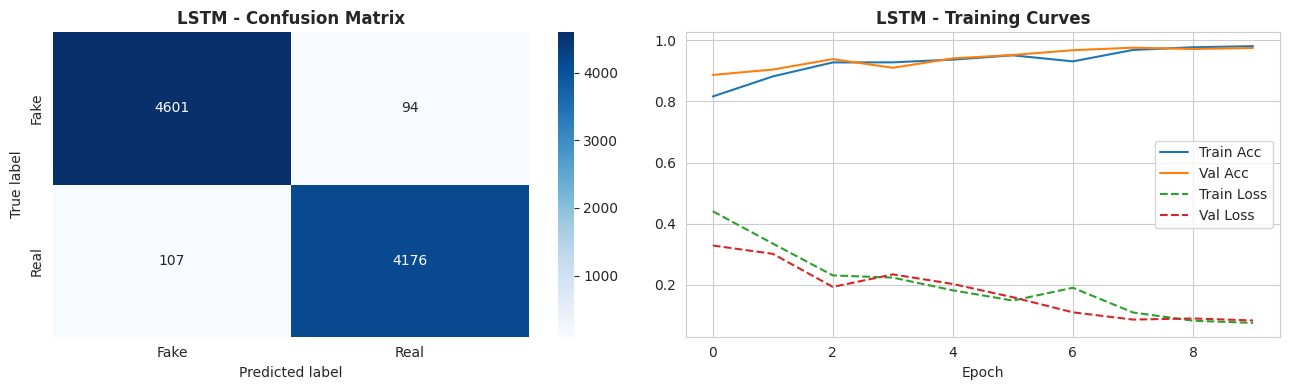

In [11]:
m = train_and_evaluate('LSTM', build_lstm)
all_metrics.append(m)

### 7.2 GRU


  Training: GRU


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 64s 125ms/step - accuracy: 0.7909 - loss: 0.4659 - val_accuracy: 0.8928 - val_loss: 0.3179 - learning_rate: 0.0010
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 125ms/step - accuracy: 0.9137 - loss: 0.2692 - val_accuracy: 0.9441 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 125ms/step - accuracy: 0.8404 - loss: 0.3326 - val_accuracy: 0.9528 - val_loss: 0.1459 - learning_rate: 0.0010
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 124ms/step - accuracy: 0.9702 - loss: 0.0977 - val_accuracy: 0.9817 - val_loss: 0.0576 - learning_rate: 0.0010
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 125ms/step - accuracy: 0.9858 - loss: 0.0473 - val_accuracy: 0.9871 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 61s 125ms/step - accuracy: 0.9908 - loss: 0.0346 - val_accuracy: 0.9898 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 62s 126ms/step - accuracy: 0.9

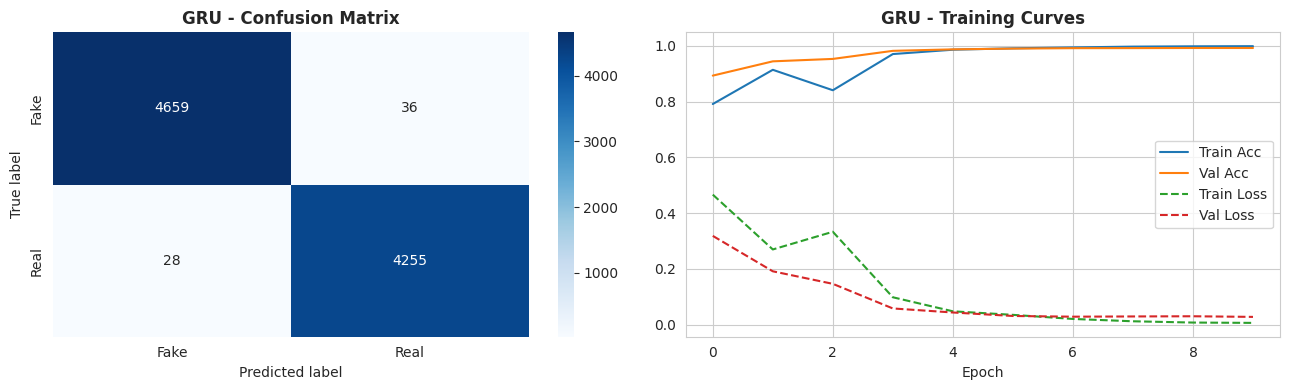

In [12]:
m = train_and_evaluate('GRU', build_gru)
all_metrics.append(m)

### 7.3 Bidirectional LSTM


  Training: Bidirectional LSTM


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 149s 296ms/step - accuracy: 0.9668 - loss: 0.0841 - val_accuracy: 0.9967 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 144s 293ms/step - accuracy: 0.9969 - loss: 0.0115 - val_accuracy: 0.9964 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 144s 293ms/step - accuracy: 0.9984 - loss: 0.0059 - val_accuracy: 0.9964 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 143s 292ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9953 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.9994 - loss: 0.0016
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
491/491 ━━━━━━━━━━━━━━━━━━━━ 143s 292ms/step - accuracy: 0.9993 - loss: 0.0020 - val_accuracy: 0.9929 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 144s 294ms/step - accuracy:

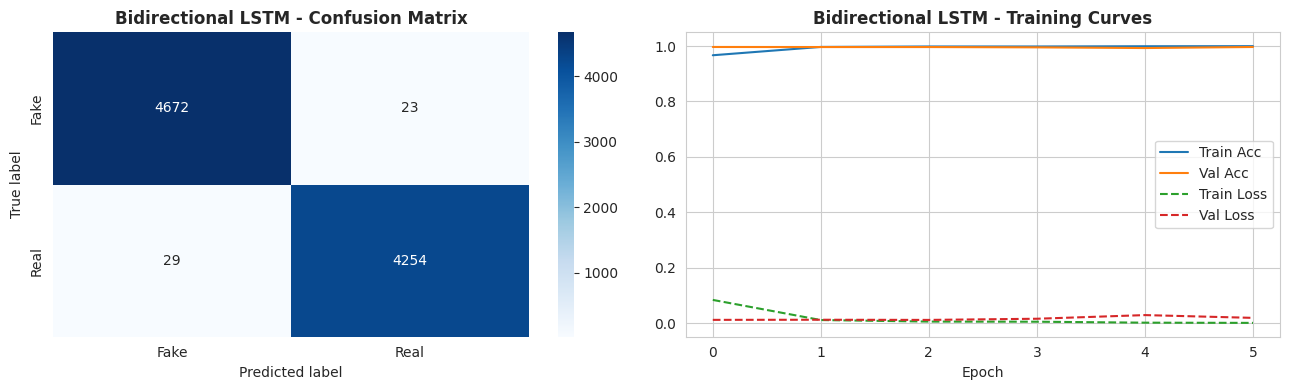

In [13]:
m = train_and_evaluate('Bidirectional LSTM', build_bilstm)
all_metrics.append(m)

### 7.4 CNN


  Training: CNN


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.9425 - loss: 0.1297 - val_accuracy: 0.9909 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.9943 - loss: 0.0177 - val_accuracy: 0.9922 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9989 - loss: 0.0047 - val_accuracy: 0.9944 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.9942 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9999 - loss: 8.5911e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.9998 - loss: 7.5601e-04 - val_accuracy: 0.9947 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 1.00

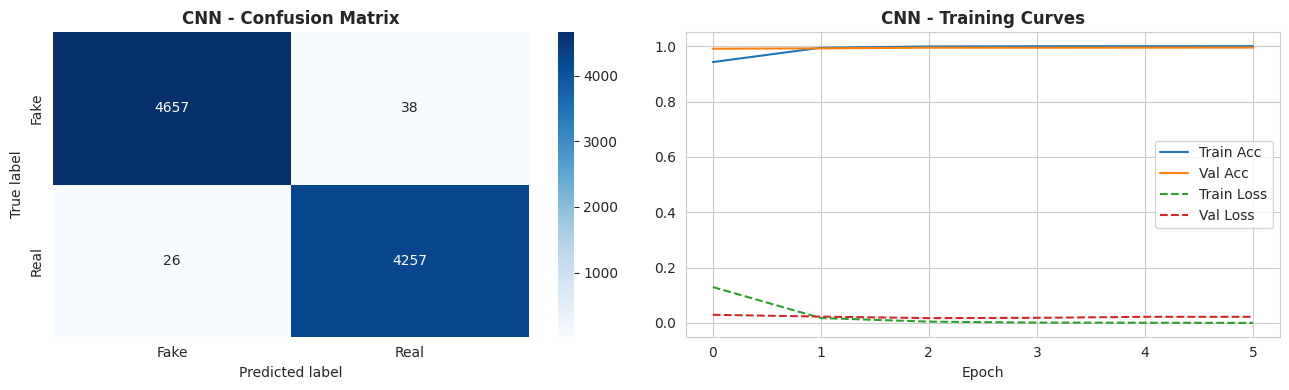

In [14]:
m = train_and_evaluate('CNN', build_cnn)
all_metrics.append(m)

## 8. Evaluation & Model Comparison

In [15]:
results = pd.DataFrame(all_metrics)
results = results.set_index('Model')
results = results.sort_values('F1', ascending=False)

display_df = results.copy()
for col in display_df.columns:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')

print('=== Model Comparison (sorted by F1) ===')
display_df

=== Model Comparison (sorted by F1) ===


,Accuracy,Precision,Recall,F1
Model,,,,
Bidirectional LSTM,0.9942,0.9946,0.9932,0.9939
CNN,0.9929,0.9912,0.9939,0.9925
GRU,0.9929,0.9916,0.9935,0.9925
LSTM,0.9776,0.9780,0.9750,0.9765
Baseline - uniform,0.4969,0.4738,0.4950,0.4842
Baseline - stratified,0.5018,0.4773,0.4674,0.4723
Baseline - most_frequent,0.5229,0.0000,0.0000,0.0000


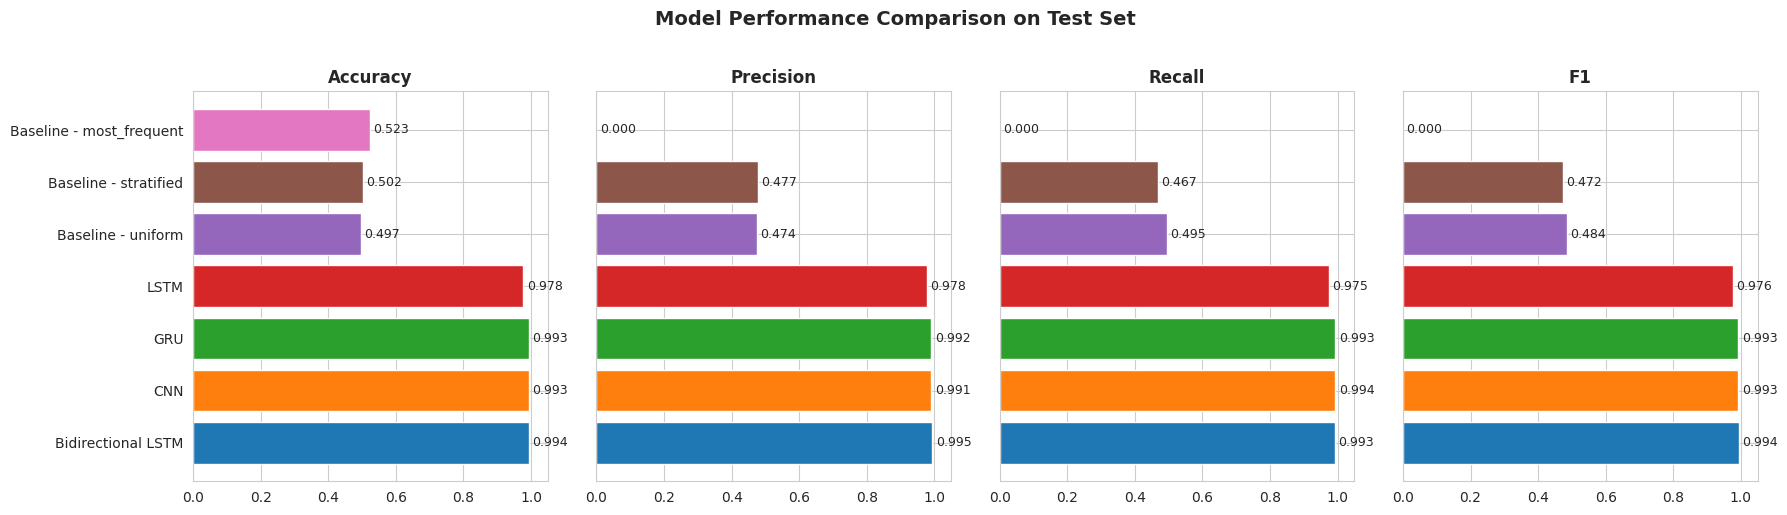

Best model by F1-score: Bidirectional LSTM  (F1 = 0.9939)


In [16]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

palette = plt.cm.tab10.colors

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    vals  = results[metric].values
    names = results.index.tolist()
    bars  = ax.barh(names, vals, color=palette[:len(names)], edgecolor='white')
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Model Performance Comparison on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_model = results.index[0]
print(f'Best model by F1-score: {best_model}  (F1 = {results.loc[best_model, "F1"]:.4f})')

## 9. Save Results

In [17]:
OUTPUT_CSV = 'model_metrics.csv'
results_reset = results.reset_index()
results_reset.to_csv(OUTPUT_CSV, index=False)
print(f'Metrics saved to: {OUTPUT_CSV}')
print(results_reset.to_string(index=False))

Metrics saved to: model_metrics.csv
                   Model  Accuracy  Precision   Recall       F1
      Bidirectional LSTM  0.994208   0.994622 0.993229 0.993925
                     CNN  0.992871   0.991153 0.993929 0.992539
                     GRU  0.992871   0.991610 0.993463 0.992536
                    LSTM  0.977612   0.977986 0.975018 0.976499
      Baseline - uniform  0.496881   0.473849 0.494980 0.484184
   Baseline - stratified  0.501782   0.477349 0.467429 0.472337
Baseline - most_frequent  0.522945   0.000000 0.000000 0.000000


## 10. Verify — Reload All Models from Saved Weights

Reload all models and test them to confirm they match training predictions.

In [18]:
# Reload all models
def build_lstm(v, e, l):
    return Sequential([Embedding(v,e,input_length=l), SpatialDropout1D(0.2),
                      LSTM(64,dropout=0.2,recurrent_dropout=0.2),
                      Dense(32,activation='relu'), Dropout(0.3), Dense(1,activation='sigmoid')
                      ], name='LSTM')

def build_gru(v, e, l):
    return Sequential([Embedding(v,e,input_length=l), SpatialDropout1D(0.2),
                      GRU(64,dropout=0.2,recurrent_dropout=0.2),
                      Dense(32,activation='relu'), Dropout(0.3), Dense(1,activation='sigmoid')
                      ], name='GRU')

def build_bilstm(v, e, l):
    return Sequential([Embedding(v,e,input_length=l), SpatialDropout1D(0.2),
                       Bidirectional(LSTM(64,dropout=0.2,recurrent_dropout=0.2)),
                       Dense(32,activation='relu'), Dropout(0.3), Dense(1,activation='sigmoid')
                       ], name='Bidirectional_LSTM')

def build_cnn(v, e, l):
    return Sequential([Embedding(v,e,input_length=l), SpatialDropout1D(0.2),
                      Conv1D(128,5,activation='relu'), GlobalMaxPooling1D(),
                      Dense(64,activation='relu'), Dropout(0.3), Dense(1,activation='sigmoid')
                      ], name='CNN')

BUILDERS = {
    'LSTM':               build_lstm,
    'GRU':                build_gru,
    'Bidirectional_LSTM':  build_bilstm,
    'CNN':                build_cnn,
}

loaded = {}
for name, build_fn in BUILDERS.items():
    weights_file = os.path.join(WEIGHTS_DIR, f'{name}.weights.h5')
    model = build_fn(vocab_size, EMBED_DIM, MAX_LEN)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    _ = model.predict(np.zeros((1, MAX_LEN), dtype='int32'), verbose=0)
    model.load_weights(weights_file)
    loaded[name] = model
    print(f'  Loaded: {name}')

print(f'\nAll models reloaded - ready for inference')

  Loaded: LSTM
  Loaded: GRU


  Loaded: Bidirectional_LSTM


  Loaded: CNN

All models reloaded - ready for inference
